In [33]:
import os

import numpy as np
import pandas as pd

import anndata
import scanpy as sc
from sklearn.neighbors import NearestCentroid
from sklearn.metrics import normalized_mutual_info_score as nmi
from scipy.spatial.distance import cdist, pdist, squareform

import matplotlib.pyplot as plt
import seaborn as sns
import plotnine as p9
import patchworklib as pw

import sys

sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io
from scLEMBAS.plotting import plot_embedding
from scLEMBAS import preprocess


In [25]:
n_cores = 12
os.environ["OMP_NUM_THREADS"] = str(n_cores)
os.environ["MKL_NUM_THREADS"] = str(n_cores)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

seed = 888
data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'

Load files:

In [26]:
tf_adata = io.read_tfad(file_name = os.path.join(data_path, 'interim', 'ID_tf_activity.h5ad'))
adata = sc.read_h5ad(os.path.join(data_path, 'processed', 'expr_scored.h5ad'))
sn_ppis = pd.read_csv(os.path.join(data_path, 'processed', 'sn_ppis.csv'), index_col = 0)

In [27]:
source_label = 'source_genesymbol'
target_label = 'target_genesymbol'
weight_label = 'mode_of_action'
stimulation_label = 'consensus_stimulation'
inhibition_label = 'consensus_inhibition'

Filter for TFs retained ni the signaling network:

In [28]:
tf_labels = tf_adata.var.index.unique().tolist()
og_n = len(tf_labels)

included_nodes = sorted(set(sn_ppis[source_label].tolist() + sn_ppis[target_label].tolist()))
tf_labels = [tf for tf in tf_labels if tf in included_nodes]
print('{} of {} TFs are present in the signaling network'.format(len(tf_labels), og_n))
tf_adata = tf_adata[:,tf_labels]


121 of 567 TFs are present in the signaling network


Embed:

In [29]:
preprocess.embed_tf_activity(tf_adata = tf_adata, scanpy_pca = False)

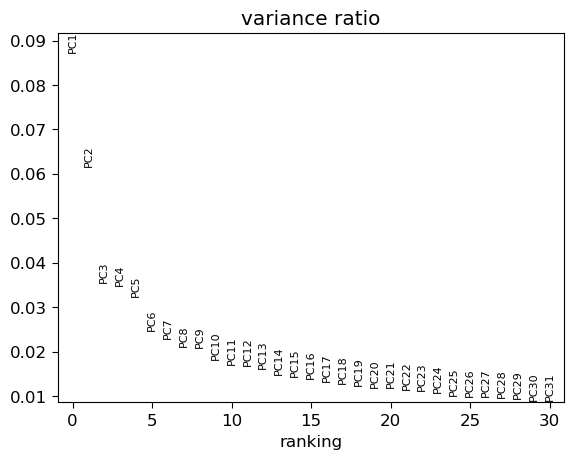

The elbow was automatically identified at PC 10


In [30]:
sc.pl.pca_variance_ratio(tf_adata)
print('The elbow was automatically identified at PC {}'.format(tf_adata.uns['pca']['pca_rank']))

Embed in UMAP space:

In [31]:
sc.pp.neighbors(tf_adata, n_pcs = tf_adata.uns['pca']['pca_rank'])
sc.tl.umap(tf_adata)

Visualize:

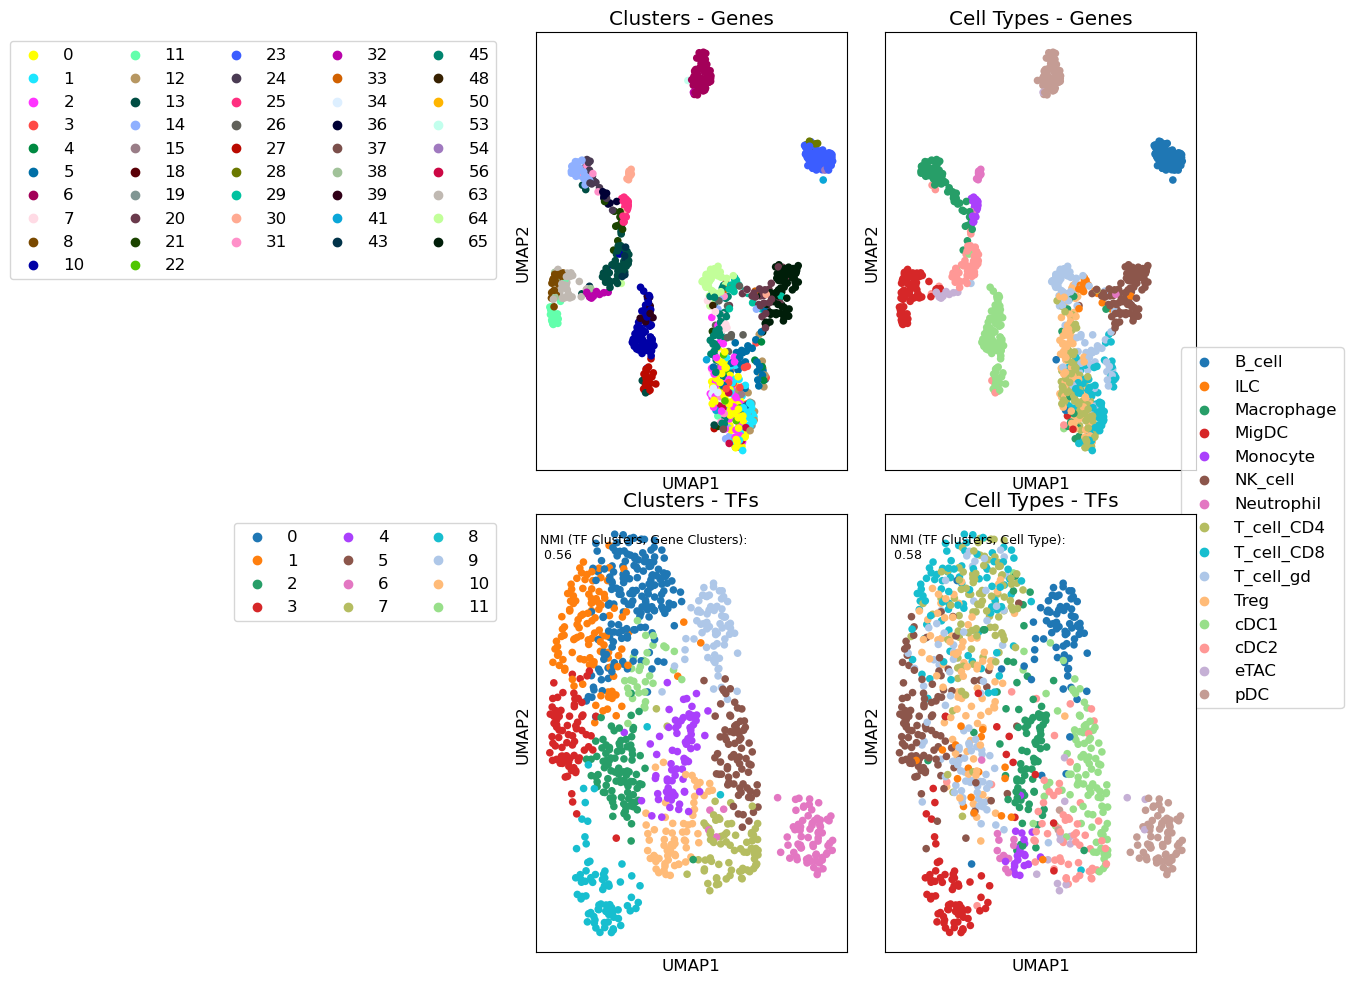

In [34]:
fig, ax = plt.subplots(ncols = 2, nrows = 2, figsize = (15, 10))

sc.pl.umap(adata, color='seurat_clusters', ax = ax[0,0], show = False)
ax[0,0].set_title('Clusters - Genes')
ax[0,0].legend(bbox_to_anchor=(-0.1, 1), ncol = 5, bbox_transform=ax[0,0].transAxes)

sc.pl.umap(adata, color='celltype', ax = ax[0,1], show = False)
ax[0,1].set_title('Cell Types - Genes')
ax[0, 1].legend(bbox_to_anchor=(1.5, 0.3), bbox_transform=ax[0,1].transAxes)

sc.pl.umap(tf_adata, color='TF_clusters', ax = ax[1,0], show = False)
ax[1,0].set_title('Clusters - TFs')
ax[1,0].legend(bbox_to_anchor=(-0.1, 1), bbox_transform=ax[1,0].transAxes, ncol = 3)
ax[1,0].annotate('NMI (TF Clusters, Gene Clusters):\n {:.2f}'.format(nmi(tf_adata.obs.TF_clusters, tf_adata.obs.seurat_clusters)),
                xy = (0.015, 0.9), xycoords='axes fraction', fontsize = 9)

sc.pl.umap(tf_adata, color='celltype', ax = ax[1,1], show = False)
ax[1,1].set_title('Cell Types - TFs')
ax[1,1].legend().set_visible(False)
ax[1,1].annotate('NMI (TF Clusters, Cell Type):\n {:.2f}'.format(nmi(tf_adata.obs.TF_clusters, tf_adata.obs.celltype)),
                xy = (0.015, 0.9), xycoords='axes fraction', fontsize = 9)

fig.tight_layout()
plt.subplots_adjust(hspace=0.1)
plt.show()

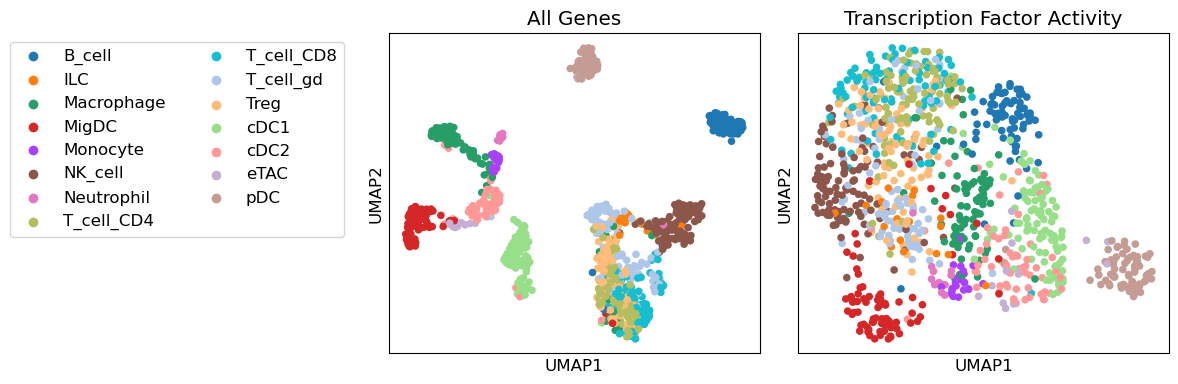

In [36]:
fig, ax = plt.subplots(ncols = 2, figsize = (12, 4))

sc.pl.umap(adata, color='celltype', ax = ax[0], show = False)
ax[0].set_title('All Genes')
ax[0].legend(bbox_to_anchor=(-0.1, 1), ncol = 2, bbox_transform=ax[0].transAxes)

sc.pl.umap(tf_adata, color='celltype', ax = ax[1], show = False)
ax[1].set_title('Transcription Factor Activity')
# ax[1].set_ylabel('').set_visible(False)
ax[1].legend(bbox_to_anchor=(-0.1, 1), ncol = 2, bbox_transform=ax[1].transAxes)
ax[1].legend().set_visible(False)

fig.tight_layout()
# plt.savefig(fname = os.path.join(data_path, 'figures', .png'), 
#             transparent = True, 
#             bbox_inches = 'tight')
plt.show()

In [38]:
io.write_tfad(tf_adata, os.path.join(data_path, 'processed', 'ID_tf_activity.h5ad'))